In [ ]:

##########################---- LOAN_APPROVAL_PREDICTION_SYSTEM ----#############################


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing, metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [2]:
# ================================
# 1. LOAD & EXPLORE DATA
# ================================
data = pd.read_csv("LoanApprovalPrediction.csv")
print("Dataset Preview:")
print(data.head())

obj = (data.dtypes == 'object')
print("\nCategorical variables:", len(list(obj[obj].index)))


Dataset Preview:
    Loan_ID Gender Married  Dependents     Education Self_Employed  \
0  LP001002   Male      No         0.0      Graduate            No   
1  LP001003   Male     Yes         1.0      Graduate            No   
2  LP001005   Male     Yes         0.0      Graduate           Yes   
3  LP001006   Male     Yes         0.0  Not Graduate            No   
4  LP001008   Male      No         0.0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N

In [3]:
# ================================
# 2. PREPROCESSING
# ================================
# Drop Loan_ID (non-predictive identifier)
data.drop(['Loan_ID'], axis=1, inplace=True)


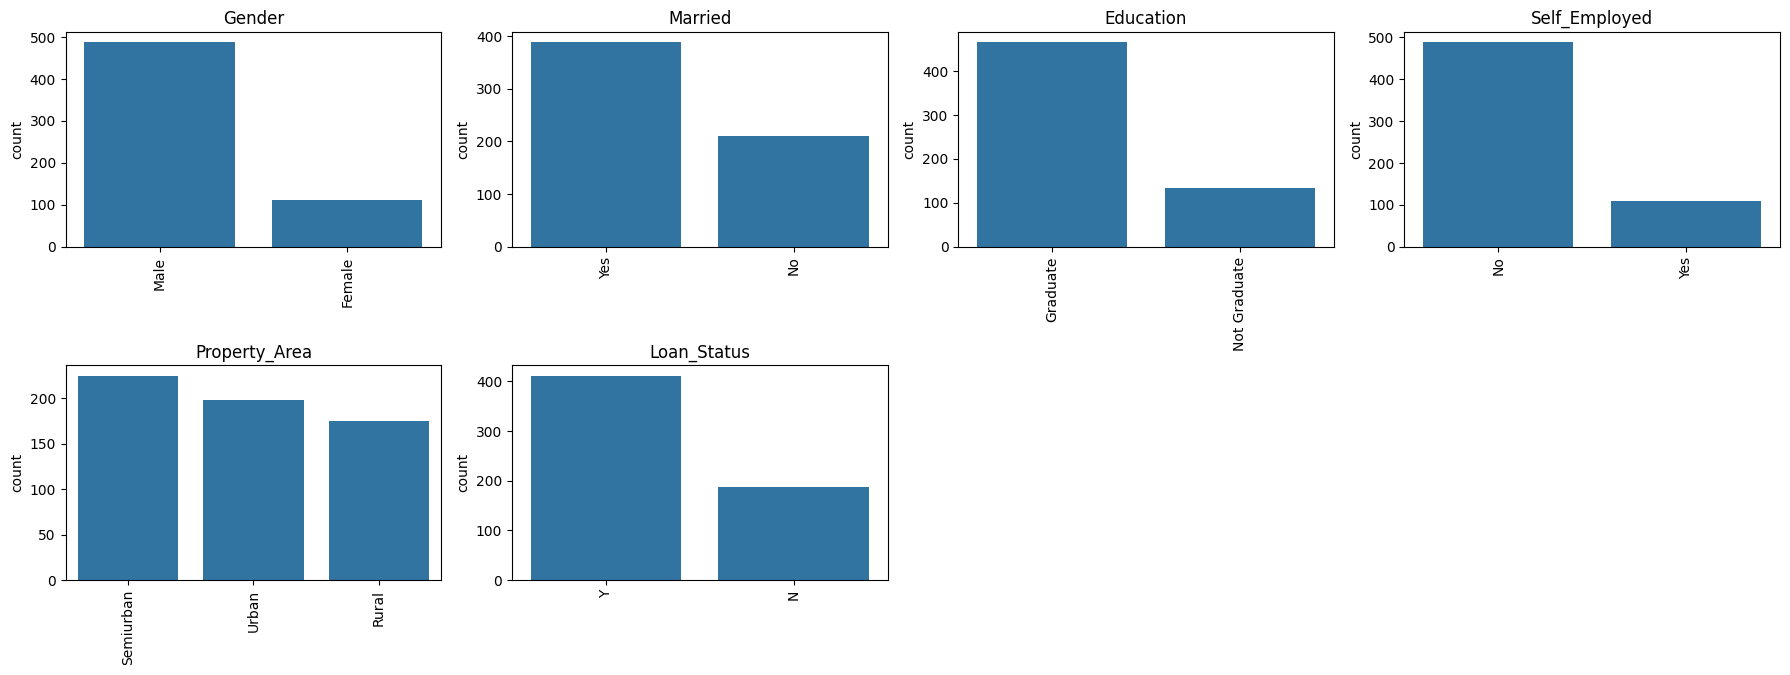

In [4]:
# --------------------------------
# 2a. Visualize Categorical Columns
# --------------------------------
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)

plt.figure(figsize=(18, 36))
for index, col in enumerate(object_cols, start=1):
    y = data[col].value_counts()
    plt.subplot(11, 4, index)
    plt.xticks(rotation=90)
    sns.barplot(x=list(y.index), y=y)
    plt.title(col)
plt.tight_layout()
plt.savefig("categorical_distributions.png", dpi=100)
plt.show()

In [5]:
# --------------------------------
# 2b. Encode Categorical Variables
# --------------------------------
label_encoder = preprocessing.LabelEncoder()
obj = (data.dtypes == 'object')
for col in list(obj[obj].index):
    data[col] = label_encoder.fit_transform(data[col])

obj = (data.dtypes == 'object')
print("\nCategorical variables after encoding:", len(list(obj[obj].index)))



Categorical variables after encoding: 0


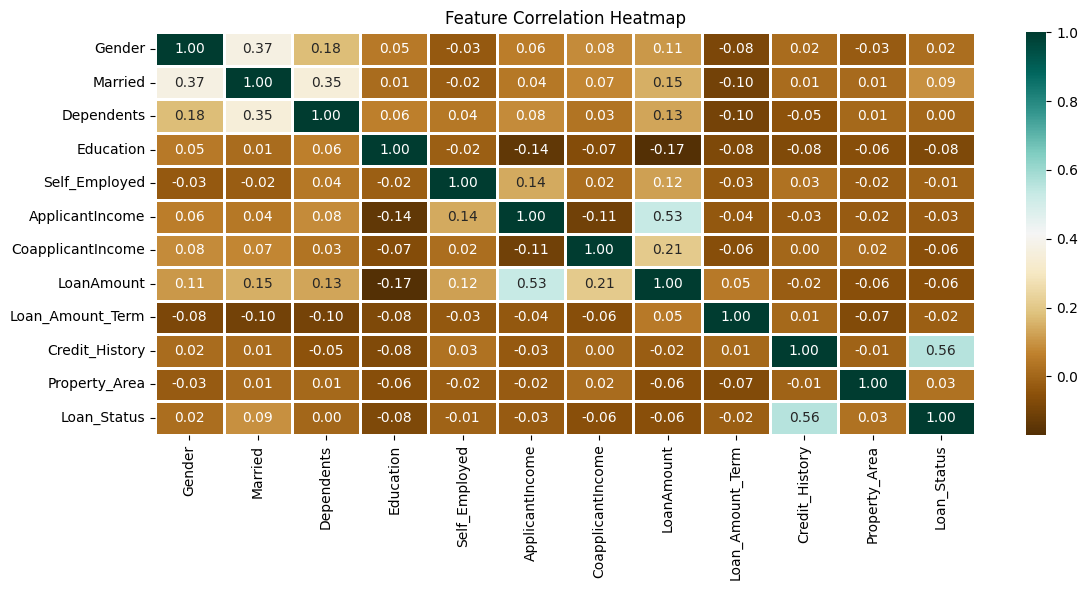

In [6]:
# --------------------------------
# 2c. Correlation Heatmap
# --------------------------------
plt.figure(figsize=(12, 6))
sns.heatmap(data.corr(), cmap='BrBG', fmt='.2f', linewidths=2, annot=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=100)
plt.show()


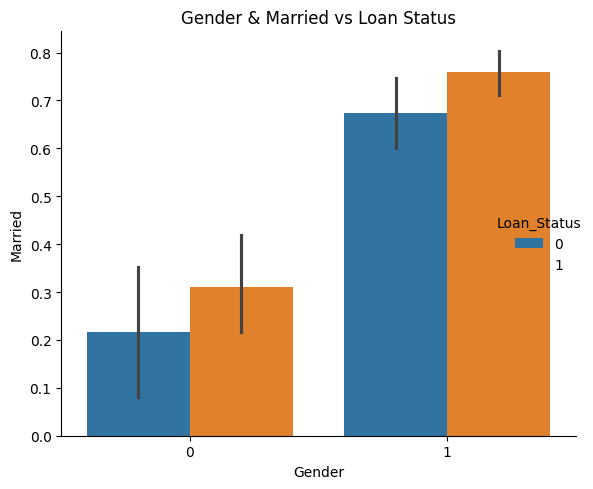

In [7]:
# --------------------------------
# 2d. Gender vs Married by Loan Status
# --------------------------------
sns.catplot(x="Gender", y="Married", hue="Loan_Status",
            kind="bar", data=data)
plt.title("Gender & Married vs Loan Status")
plt.tight_layout()
plt.savefig("gender_married_loan.png", dpi=100)
plt.show()


In [8]:
# --------------------------------
# 2e. Handle Missing Values
# --------------------------------
for col in data.columns:
    data[col] = data[col].fillna(data[col].mean())

print("\nMissing values after imputation:")
print(data.isna().sum())



Missing values after imputation:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [10]:
# ================================
# 3. FEATURE SELECTION & SPLIT
# ================================
FEATURES = ['Credit_History', 'ApplicantIncome', 'LoanAmount', 'Education']
TARGET   = 'Loan_Status'

X = data[FEATURES]
Y = data[TARGET]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=1
)

print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")



Train size: (478, 4), Test size: (120, 4)


In [11]:
# ================================
# 4. TRAIN MODELS
# ================================
models = {
    "Random Forest":     RandomForestClassifier(n_estimators=7, criterion='entropy', random_state=7),
    "KNN":               KNeighborsClassifier(n_neighbors=3),
    "SVM":               SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

print("\n--- Training Accuracy ---")
for name, clf in models.items():
    clf.fit(X_train, Y_train)
    Y_pred_train = clf.predict(X_train)
    acc = metrics.accuracy_score(Y_train, Y_pred_train)
    print(f"{name:22s} Training Accuracy = {acc * 100:.2f}%")



--- Training Accuracy ---
Random Forest          Training Accuracy = 96.44%
KNN                    Training Accuracy = 79.50%
SVM                    Training Accuracy = 67.99%
Logistic Regression    Training Accuracy = 79.50%


In [12]:
# ================================
# 5. EVALUATE & SELECT BEST MODEL
# ================================
print("\n--- Test Accuracy & Best Model Selection ---")
best_model    = None
best_accuracy = 0
best_name     = ""

for name, clf in models.items():
    Y_pred_test = clf.predict(X_test)
    acc = metrics.accuracy_score(Y_test, Y_pred_test)
    print(f"{name:22s} Test Accuracy = {acc * 100:.2f}%")
    if acc > best_accuracy:
        best_accuracy = acc
        best_model    = clf
        best_name     = name

print(f"\n✅ Best Model Selected : {best_name}")
print(f"   Best Test Accuracy  : {best_accuracy * 100:.2f}%")



--- Test Accuracy & Best Model Selection ---
Random Forest          Test Accuracy = 77.50%
KNN                    Test Accuracy = 59.17%
SVM                    Test Accuracy = 72.50%
Logistic Regression    Test Accuracy = 85.83%

✅ Best Model Selected : Logistic Regression
   Best Test Accuracy  : 85.83%


In [13]:
# ================================
# 6. USER INPUT & PREDICTION
# ================================
print("\n===== Enter Applicant Details =====")
try:
    credit    = float(input("Credit History (1 = Good, 0 = Bad)    : "))
    income    = float(input("Applicant Income (monthly)            : "))
    loan      = float(input("Loan Amount (in thousands)            : "))
    education = int(input("Education (1 = Graduate, 0 = Not)    : "))

    # Validate inputs
    if credit not in [0, 1]:
        raise ValueError("Credit History must be 0 or 1.")
    if income < 0 or loan < 0:
        raise ValueError("Income and Loan Amount must be non-negative.")
    if education not in [0, 1]:
        raise ValueError("Education must be 0 or 1.")

    input_data = np.array([[credit, income, loan, education]])
    prediction = best_model.predict(input_data)[0]

    print("\n" + "=" * 40)
    if prediction == 1:
        print("✅ Loan APPROVED")
    else:
        print("❌ Loan REJECTED")
    print(f"   (Predicted by: {best_name})")
    print("=" * 40)

except ValueError as e:
    print(f"\n⚠️  Invalid input: {e}")


===== Enter Applicant Details =====


Credit History (1 = Good, 0 = Bad)    :  1
Applicant Income (monthly)            :  30000
Loan Amount (in thousands)            :  234
Education (1 = Graduate, 0 = Not)    :  0



✅ Loan APPROVED
   (Predicted by: Logistic Regression)


C:\Users\hemra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
